## Medical Image Analysis: Pneumonia Detection and XAI

###  Dataset Download and Preparation

We'll use the 'Chest X-Ray Images (Pneumonia)' dataset from Kaggle. This dataset contains X-ray images of children, categorized as either 'Pneumonia' or 'Normal'.

First, we need to install the `kaggle` library and set up the API for downloading.

In [1]:
!pip install kaggle --quiet

To download the dataset, you'll need a Kaggle API token. Please follow these steps:

1.  Go to Kaggle: [https://www.kaggle.com/](https://www.kaggle.com/)
2.  Log in or register.
3.  Click on your profile picture in the top right corner and select "My Account".
4.  Scroll down to the "API" section and click "Create New API Token". This will download a `kaggle.json` file.
5.  Upload this `kaggle.json` file to your Colab environment. You can do this by clicking the folder icon on the left panel, then the "Upload to session storage" icon.

Once the `kaggle.json` file is uploaded, the following code will set up your Kaggle API credentials.

In [7]:
import os

# Ensure the .kaggle directory exists
os.makedirs('/root/.kaggle', exist_ok=True)

# Move kaggle.json to the correct directory (assuming it's uploaded to /content/)
# If you uploaded it manually using the file browser, it will be in /content/
# If you run this cell again, it might give an error if kaggle.json is already there,
# but it won't affect functionality.
!mv kaggle.json /root/.kaggle/

# Set permissions
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API configured.")

Kaggle API configured.


Now we can download the dataset. The dataset ID for 'Chest X-Ray Images (Pneumonia)' is `paultimothymooney/chest-xray-pneumonia`.

In [9]:
from pathlib import Path
import os

DATASET_NAME = 'paultimothymooney/chest-xray-pneumonia'
DATASET_PATH = Path('chest_xray')

# Download the dataset
!kaggle datasets download -d {DATASET_NAME}

# Unzip the dataset
!unzip -q chest-xray-pneumonia.zip -d {DATASET_PATH}

print(f"Dataset downloaded and extracted to: {DATASET_PATH}")
print(f"Directory contents: {os.listdir(DATASET_PATH)}")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:02<00:00, 39.7MB/s]

Dataset downloaded and extracted to: chest_xray
Directory contents: ['chest_xray']


###  Data Preprocessing and Loaders

In [12]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Define transformations for the dataset
# These are standard transformations for ImageNet pretrained models.
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Load the dataset
# The dataset structure is: chest_xray/chest_xray/{train, val, test}/{NORMAL, PNEUMONIA}
full_train_dataset = datasets.ImageFolder(root=DATASET_PATH / 'chest_xray' / 'train', transform=train_transforms)
val_dataset_raw = datasets.ImageFolder(root=DATASET_PATH / 'chest_xray' / 'val', transform=val_test_transforms)
test_dataset = datasets.ImageFolder(root=DATASET_PATH / 'chest_xray' / 'test', transform=val_test_transforms)

# Combine val_dataset_raw into full_train_dataset and then split again to ensure sufficient val data
# This is a common practice when the original 'val' set is very small.
combined_train_val_dataset = torch.utils.data.ConcatDataset([full_train_dataset, val_dataset_raw])

# Define split ratios for train and validation
train_size = int(0.8 * len(combined_train_val_dataset))
val_size = len(combined_train_val_dataset) - train_size

train_dataset, val_dataset = random_split(combined_train_val_dataset, [train_size, val_size])


batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

class_names = full_train_dataset.classes

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Classes: {class_names}")

Number of training samples: 4185
Number of validation samples: 1047
Number of test samples: 624
Classes: ['NORMAL', 'PNEUMONIA']


Let's visualize some sample images from the training dataset to make sure everything is loading correctly.

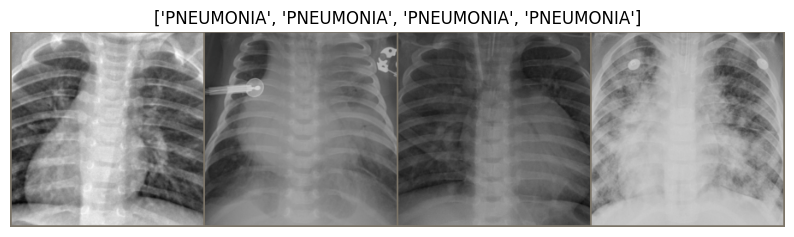

In [13]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Get a batch of training data
inputs, classes = next(iter(train_loader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs[:4]) # Show first 4 images

plt.figure(figsize=(10, 5))
imshow(out, title=[class_names[x] for x in classes[:4]])
plt.show()

###  Build and Train a Classification Model

For this task, we will fine-tune a pre-trained ResNet-18 model. Using a pre-trained model on a large dataset like ImageNet and then fine-tuning it for our specific task (transfer learning) is a common and effective approach in image classification, especially with limited medical imaging data. ResNet-18 is a good balance between complexity and performance.

In [16]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import torch # Import torch to define DEVICE

# Define DEVICE here as it's used in this cell
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load a pre-trained ResNet-18 model
model_pneumonia = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Modify the final fully connected layer for binary classification
# The original ResNet has 1000 output classes (ImageNet)
# We need 2 output classes: 'NORMAL' and 'PNEUMONIA'
num_ftrs = model_pneumonia.fc.in_features
model_pneumonia.fc = nn.Linear(num_ftrs, len(class_names))

# Move the model to the appropriate device (CPU or GPU)
model_pneumonia = model_pneumonia.to(DEVICE)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pneumonia.parameters(), lr=0.001)

print("Pneumonia classification model (ResNet-18) initialized.")
print(f"Output layer changed to: {model_pneumonia.fc}")

Pneumonia classification model (ResNet-18) initialized.
Output layer changed to: Linear(in_features=512, out_features=2, bias=True)


###  Train the Model

In [17]:
import time
import copy

def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model if it's the best accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

            # Save history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# Train the model
num_epochs = 10 # You can adjust this number
model_pneumonia_trained, history = train_model(
    model_pneumonia, criterion, optimizer, train_loader, val_loader, num_epochs=num_epochs
)

print("Model training complete.")

Epoch 0/9
----------
train Loss: 0.1556 Acc: 0.9446
val Loss: 0.1034 Acc: 0.9618

Epoch 1/9
----------
train Loss: 0.0887 Acc: 0.9687
val Loss: 0.0692 Acc: 0.9723

Epoch 2/9
----------
train Loss: 0.0716 Acc: 0.9732
val Loss: 0.1122 Acc: 0.9675

Epoch 3/9
----------
train Loss: 0.0794 Acc: 0.9711
val Loss: 0.1422 Acc: 0.9522

Epoch 4/9
----------
train Loss: 0.0530 Acc: 0.9811
val Loss: 0.1817 Acc: 0.9427

Epoch 5/9
----------
train Loss: 0.0583 Acc: 0.9802
val Loss: 0.0899 Acc: 0.9704

Epoch 6/9
----------
train Loss: 0.0434 Acc: 0.9838
val Loss: 0.1473 Acc: 0.9503

Epoch 7/9
----------
train Loss: 0.0607 Acc: 0.9737
val Loss: 0.0725 Acc: 0.9752

Epoch 8/9
----------
train Loss: 0.0471 Acc: 0.9830
val Loss: 0.0829 Acc: 0.9685

Epoch 9/9
----------
train Loss: 0.0289 Acc: 0.9871
val Loss: 0.1217 Acc: 0.9628

Training complete in 13m 54s
Best val Acc: 0.9752
Model training complete.


###  Evaluate the Model

In [18]:
def evaluate_model(model, test_loader, criterion):
    model.eval()  # Set model to evaluate mode
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.no_grad():
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    total_loss = running_loss / len(test_loader.dataset)
    total_acc = running_corrects.double() / len(test_loader.dataset)

    print(f'Test Loss: {total_loss:.4f} Acc: {total_acc:.4f}')
    return total_loss, total_acc

# Evaluate the trained model on the test set
test_loss, test_acc = evaluate_model(model_pneumonia_trained, test_loader, criterion)

print(f"Model evaluation complete. Test Accuracy: {test_acc:.4f}")

Test Loss: 0.8705 Acc: 0.7901
Model evaluation complete. Test Accuracy: 0.7901


###  Explainable AI (XAI) with Grad-CAM

We will now use Grad-CAM to understand which parts of the X-ray images are most important for the model's pneumonia predictions. We'll adapt the `GradCAM` class and `compute_gradcam` function defined earlier for our `model_pneumonia_trained`.

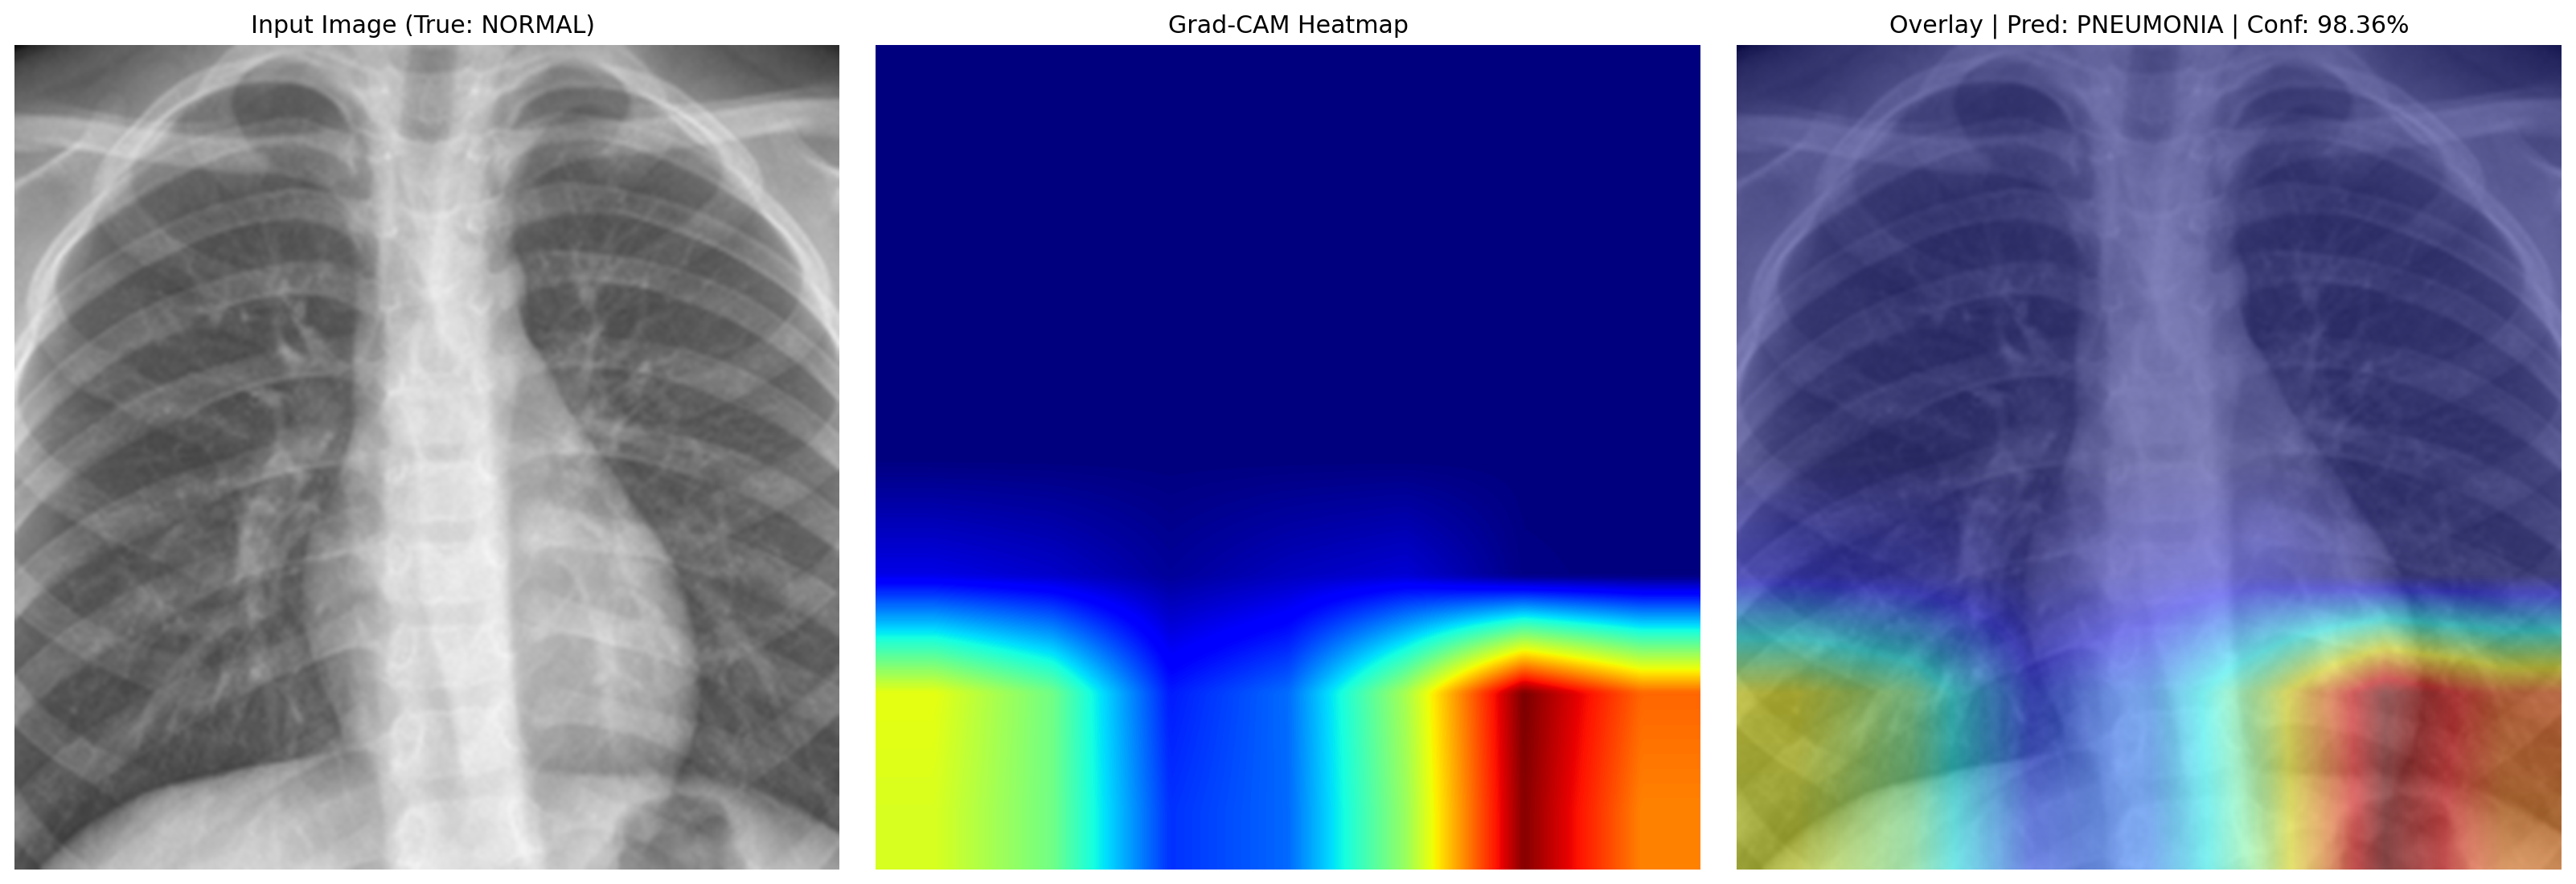

In [24]:
import random
import torchvision
import torch
import torch.nn.functional as F
import numpy as np
import cv2
from typing import Optional

# CONFIG dictionary, re-defined here to resolve NameError
CONFIG = {
    "image_source": "https://cdn.pixabay.com/photo/2023/06/01/06/22/british-shorthair-8032816_640.jpg?crop=0.754xw:1.00xh;0.0651xw,0&resize=1200:*",
    "max_long_side": 900,      # Downscale only (never upscale). Use None for original resolution.
    "display_dpi": 180,
    "overlay_alpha": 0.45,
    "target_class": None,      # None means model prediction
}


# Definitions from earlier cell (eOZef3KHixjG) to resolve NameError
class GradCAM:
    def __init__(self, model: torch.nn.Module, layer: torch.nn.Module):
        """
        Initializes Grad-CAM by attaching hooks to a target convolutional layer.

        Args:
            model : Trained CNN model
            layer : Target convolutional layer (usually last conv layer)
        """
        self.model = model
        self.layer = layer

        # Will store forward activations (feature maps A^k)
        self.activations = None

        # Will store gradients d(y^c)/d(A^k)
        self.gradients = None

        # Register forward hook → saves feature maps during forward pass
        self._fwd = self.layer.register_forward_hook(self._save_activations)

        # Register backward hook → saves gradients during backward pass
        self._bwd = self.layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, inp, out):
        """
        Hook function to save activations (feature maps).

        out shape: (batch_size, channels, height, width)
        """
        self.activations = out.detach()

    def _save_gradients(self, module, grad_in, grad_out):
        """
        Hook function to save gradients.

        grad_out[0] contains gradients of the output w.r.t feature maps:
        d(y^c) / d(A^k)
        """
        self.gradients = grad_out[0].detach()

    def remove(self):
        """
        Removes hooks to prevent memory leaks.
        """
        self._fwd.remove()
        self._bwd.remove()

def compute_gradcam(
      model: torch.nn.Module,
      image_tensor: torch.Tensor,
      gradcam: GradCAM,
      target_class: Optional[int] = None,
      eps: float = 1e-8,
  ):
    """
    Computes Grad-CAM heatmap for a given image and model.

    Args:
        model         : Trained CNN model
        image_tensor  : Input image (1, C, H, W)
        gradcam       : GradCAM object with hooks attached
        target_class  : Class index to visualize (None → predicted class)
        eps           : Small value to avoid division by zero

    Returns:
        cam           : Grad-CAM heatmap (H, W)
        pred_idx      : Predicted class index
        class_idx     : Target class used for Grad-CAM
        confidence    : Softmax probability of target class
    """

    # Reset gradients from previous runs
    model.zero_grad(set_to_none=True)

    # Forward pass
    logits = model(image_tensor)

    # Convert logits to probabilities
    probs = F.softmax(logits, dim=1)

    # Get predicted class
    pred_idx = int(torch.argmax(logits, dim=1).item())

    # Use predicted class unless user specifies another class
    class_idx = pred_idx if target_class is None else int(target_class)

    # Confidence score for selected class
    confidence = float(probs[0, class_idx].item())

    # Select score for target class (y^c)
    score = logits[0, class_idx]

    # Backward pass → computes gradients w.r.t feature maps
    score.backward()

    # Retrieve stored activations and gradients
    acts = gradcam.activations[0]    # Feature maps A^k → shape: (C, H, W)
    grads = gradcam.gradients[0]     # Gradients → shape: (C, H, W)

    # Compute importance weights (alpha_k^c)
    # Global Average Pooling over spatial dimensions
    alpha = grads.mean(dim=(1, 2), keepdim=True)

    # Compute weighted combination of feature maps
    # L^c = ReLU( sum_k (alpha_k^c * A^k) )
    cam = (alpha * acts).sum(dim=0)

    # Keep only positive contributions
    cam = F.relu(cam)

    # Normalize heatmap to range [0, 1]
    cam = cam - cam.min()
    cam = cam / (cam.max() + eps)

    return cam.cpu().numpy(), pred_idx, class_idx, confidence


def overlay_cam(image_rgb: np.ndarray, cam: np.ndarray, alpha: float = 0.45):
    h, w = image_rgb.shape[:2]
    # Resize CAM to image size for visualization only.
    cam_resized = cv2.resize(cam.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
    heat_u8 = np.uint8(np.clip(cam_resized, 0, 1) * 255)
    heat = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    overlay = (1 - alpha) * image_rgb + alpha * heat
    return np.clip(cam_resized, 0, 1), np.clip(overlay, 0, 1)


# Find the last convolutional layer for ResNet-18
# For ResNet-18, a good target layer for Grad-CAM is often the last convolutional block, e.g., layer4[-1].conv2
target_layer_pneumonia = model_pneumonia_trained.layer4[-1].conv2

# Set up GradCAM for the pneumonia model
cam_engine_pneumonia = GradCAM(model_pneumonia_trained, target_layer_pneumonia)

# Get a random image from the test set for explanation
# Ensure we have a batch to iterate from
if not hasattr(test_loader, '_iter'):
    test_loader_iter = iter(test_loader)
else:
    test_loader_iter = test_loader._iter

sample_inputs, sample_labels = next(test_loader_iter)
sample_input = sample_inputs[0].unsqueeze(0).to(DEVICE)
sample_label = sample_labels[0].item()

# Compute Grad-CAM
cam_map_pneumonia, pred_idx_pneumonia, class_idx_pneumonia, confidence_pneumonia = compute_gradcam(
    model=model_pneumonia_trained,
    image_tensor=sample_input,
    gradcam=cam_engine_pneumonia,
    target_class=None, # Use model's predicted class
)
cam_engine_pneumonia.remove()

# Convert tensor to displayable image for overlay
# Reuse the imshow helper for normalization
def denormalize_image(tensor_image):
    # Clone the tensor to avoid modifying the original
    img = tensor_image.clone().cpu().squeeze(0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

image_display_pneumonia = denormalize_image(sample_input)

# Overlay Grad-CAM on the image
cam_resized_pneumonia, blended_pneumonia = overlay_cam(
    image_rgb=image_display_pneumonia,
    cam=cam_map_pneumonia,
    alpha=CONFIG["overlay_alpha"],
)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=CONFIG["display_dpi"])
axes[0].imshow(image_display_pneumonia, interpolation="lanczos")
axes[0].set_title(f"Input Image (True: {class_names[sample_label]}) ")
axes[0].axis("off")

axes[1].imshow(cam_resized_pneumonia, cmap="jet", interpolation="bilinear")
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(blended_pneumonia, interpolation="lanczos")
axes[2].set_title(
    f"Overlay | Pred: {class_names[pred_idx_pneumonia]} | Conf: {confidence_pneumonia:.2%}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Explainable AI (XAI) with LIME

Next, we'll use Local Interpretable Model-agnostic Explanations (LIME). LIME helps us understand the predictions of *any* classifier by approximating it locally with an interpretable model. For image data, it perturbs the input image and observes how the model's prediction changes.

In [25]:
!pip install lime --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


  0%|          | 0/1000 [00:00<?, ?it/s]

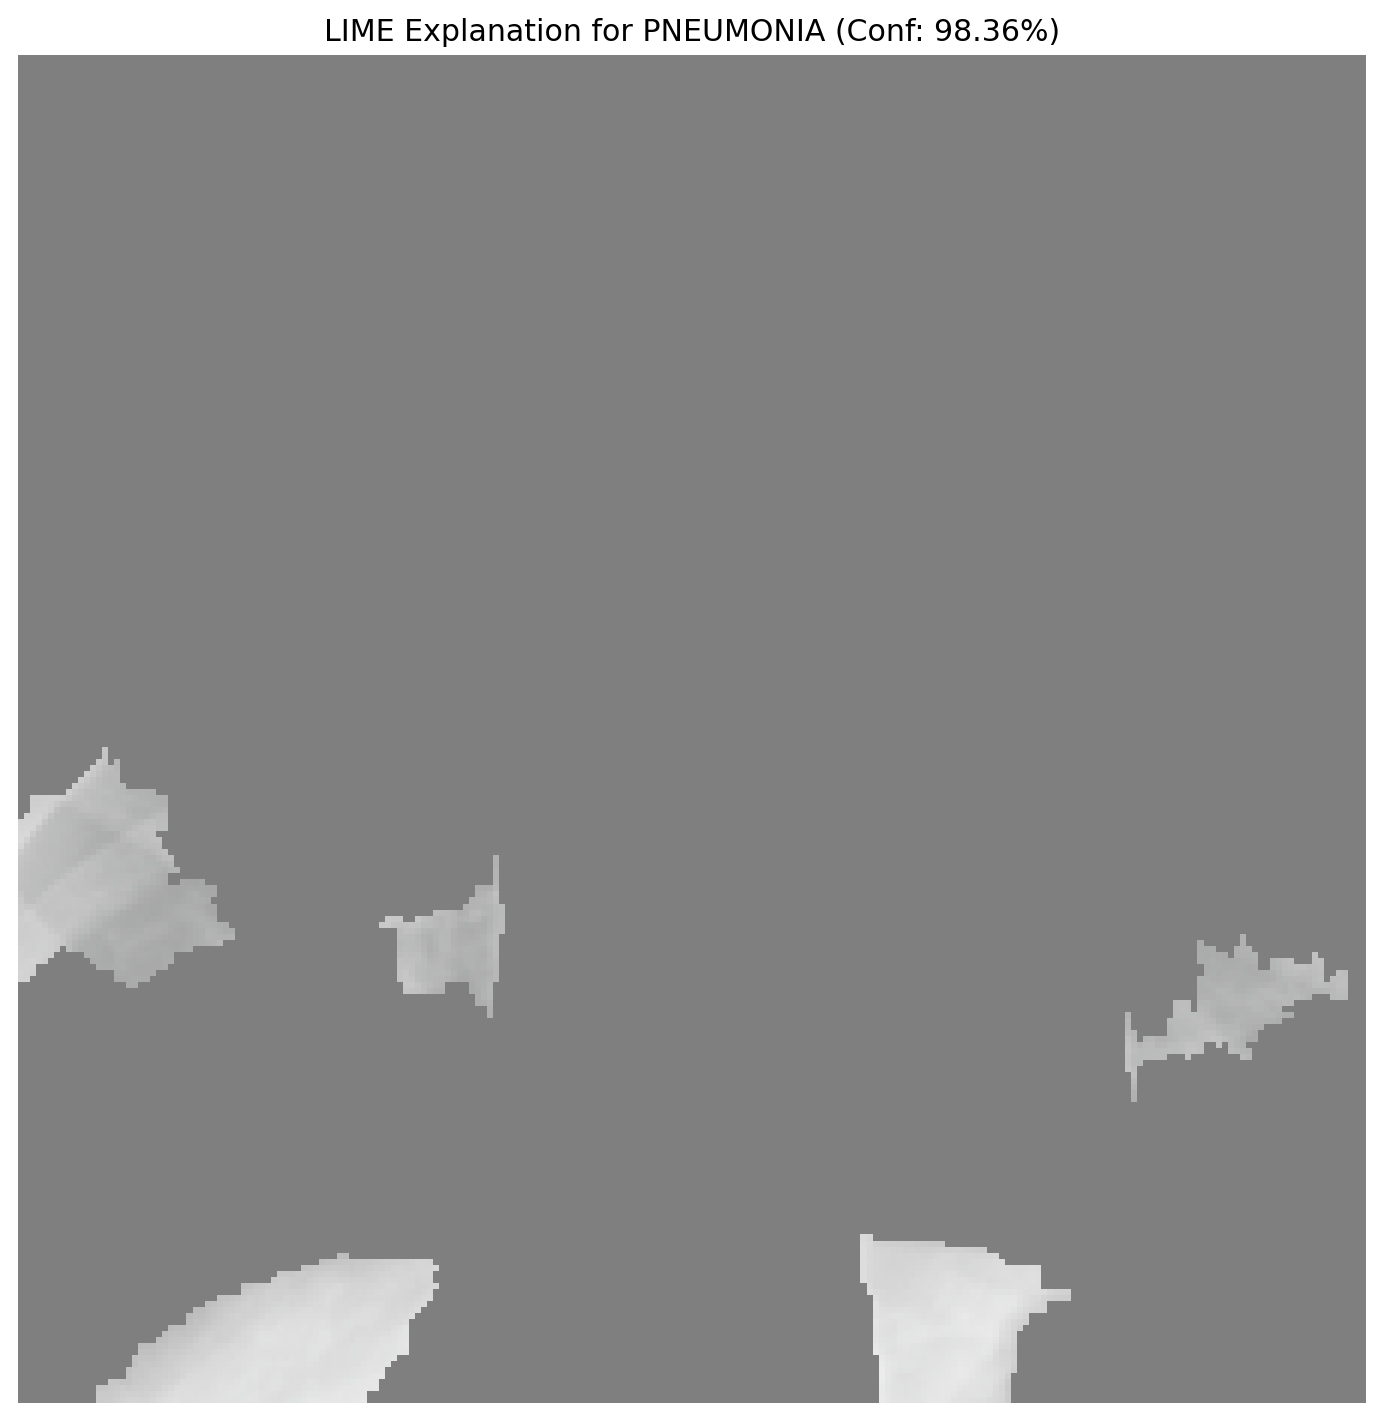

In [26]:
import lime
import lime.lime_image

# Define a prediction function for LIME
# LIME requires a function that takes a numpy array of (N, H, W, C) images
# and returns the prediction probabilities for each class (N, num_classes).

def predict_fn(images):
    # Convert numpy array (H, W, C) to torch tensor (N, C, H, W)
    # LIME expects images in (H, W, C) format, and already denormalized
    # We need to normalize them for our model.

    # First, undo the denormalization from earlier if the input is already denormalized
    # If LIME provides normalized images, this step is not needed.
    # LIME usually passes images in the range [0, 1] if given a preprocessed image.

    # Re-normalize for our model's expected input
    # Use the same mean and std as the original transforms
    mean_torch = torch.tensor([0.485, 0.456, 0.406]).to(DEVICE).view(1, 3, 1, 1)
    std_torch = torch.tensor([0.229, 0.224, 0.225]).to(DEVICE).view(1, 3, 1, 1)

    # Convert numpy (N, H, W, C) to torch tensor (N, C, H, W)
    torch_images = torch.from_numpy(images).float().permute(0, 3, 1, 2).to(DEVICE)

    # Normalize the images
    torch_images = (torch_images - mean_torch) / std_torch

    model_pneumonia_trained.eval()
    with torch.no_grad():
        logits = model_pneumonia_trained(torch_images)
    probs = torch.nn.functional.softmax(logits, dim=1)
    return probs.cpu().numpy()


# Create a LIME Image Explainer
explainer = lime.lime_image.LimeImageExplainer()

# Get the same sample input image as used for Grad-CAM (in numpy format, 0-1 range)
# sample_input is (1, C, H, W) tensor, denormalized_image expects (C, H, W) tensor, then converts to (H, W, C) numpy
# LIME explainer.explain_instance expects (H, W, C) numpy in the range [0, 1]
image_for_lime = denormalize_image(sample_input)

# Generate explanation for the predicted class
# Ensure the predicted class index matches LIME's expectation
explanation = explainer.explain_instance(
    image_for_lime,
    predict_fn,
    top_labels=1, # Explain the top predicted class
    hide_color=0, # Color for parts to hide
    num_samples=1000 # Number of perturbed samples for explanation
)

# Get image and mask for the top predicted class
# LIME returns (image, mask) tuples for each class in top_labels
# Here, we only requested top_labels=1, so we take the first element.
# LIME's get_image_and_mask expects class_id, positive_only, num_features, hide_rest
# The class_idx_pneumonia is the predicted class from the model.

# Get the image and mask for the predicted class
# We'll visualize the positive contributions of the predicted class

# LIME often gives (0, 1) as class labels based on its internal mapping,
# but our model uses the actual class indices.
# Let's verify the mapping or use the model's pred_idx_pneumonia

# Lime's explanation.top_labels[0][0] gives the predicted class label according to Lime's internal sorting.
# Use the model's actual predicted class for consistency if possible.
# For binary classification, Lime's class 0 is 'NORMAL', class 1 is 'PNEUMONIA'.
# Our `class_names` are ['NORMAL', 'PNEUMONIA'], so indices match.

temp_1, mask_lime = explanation.get_image_and_mask(
    class_idx_pneumonia,
    positive_only=True,
    num_features=5,
    hide_rest=True
)

# Visualize LIME explanation
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=CONFIG["display_dpi"])
ax.imshow(temp_1 / 2 + 0.5) # LIME's image output is often -1 to 1, scale to 0-1
ax.set_title(f"LIME Explanation for {class_names[class_idx_pneumonia]} (Conf: {confidence_pneumonia:.2%})")
ax.axis('off')
plt.tight_layout()
plt.show()

### Combined XAI Visualization (Grad-CAM and LIME)

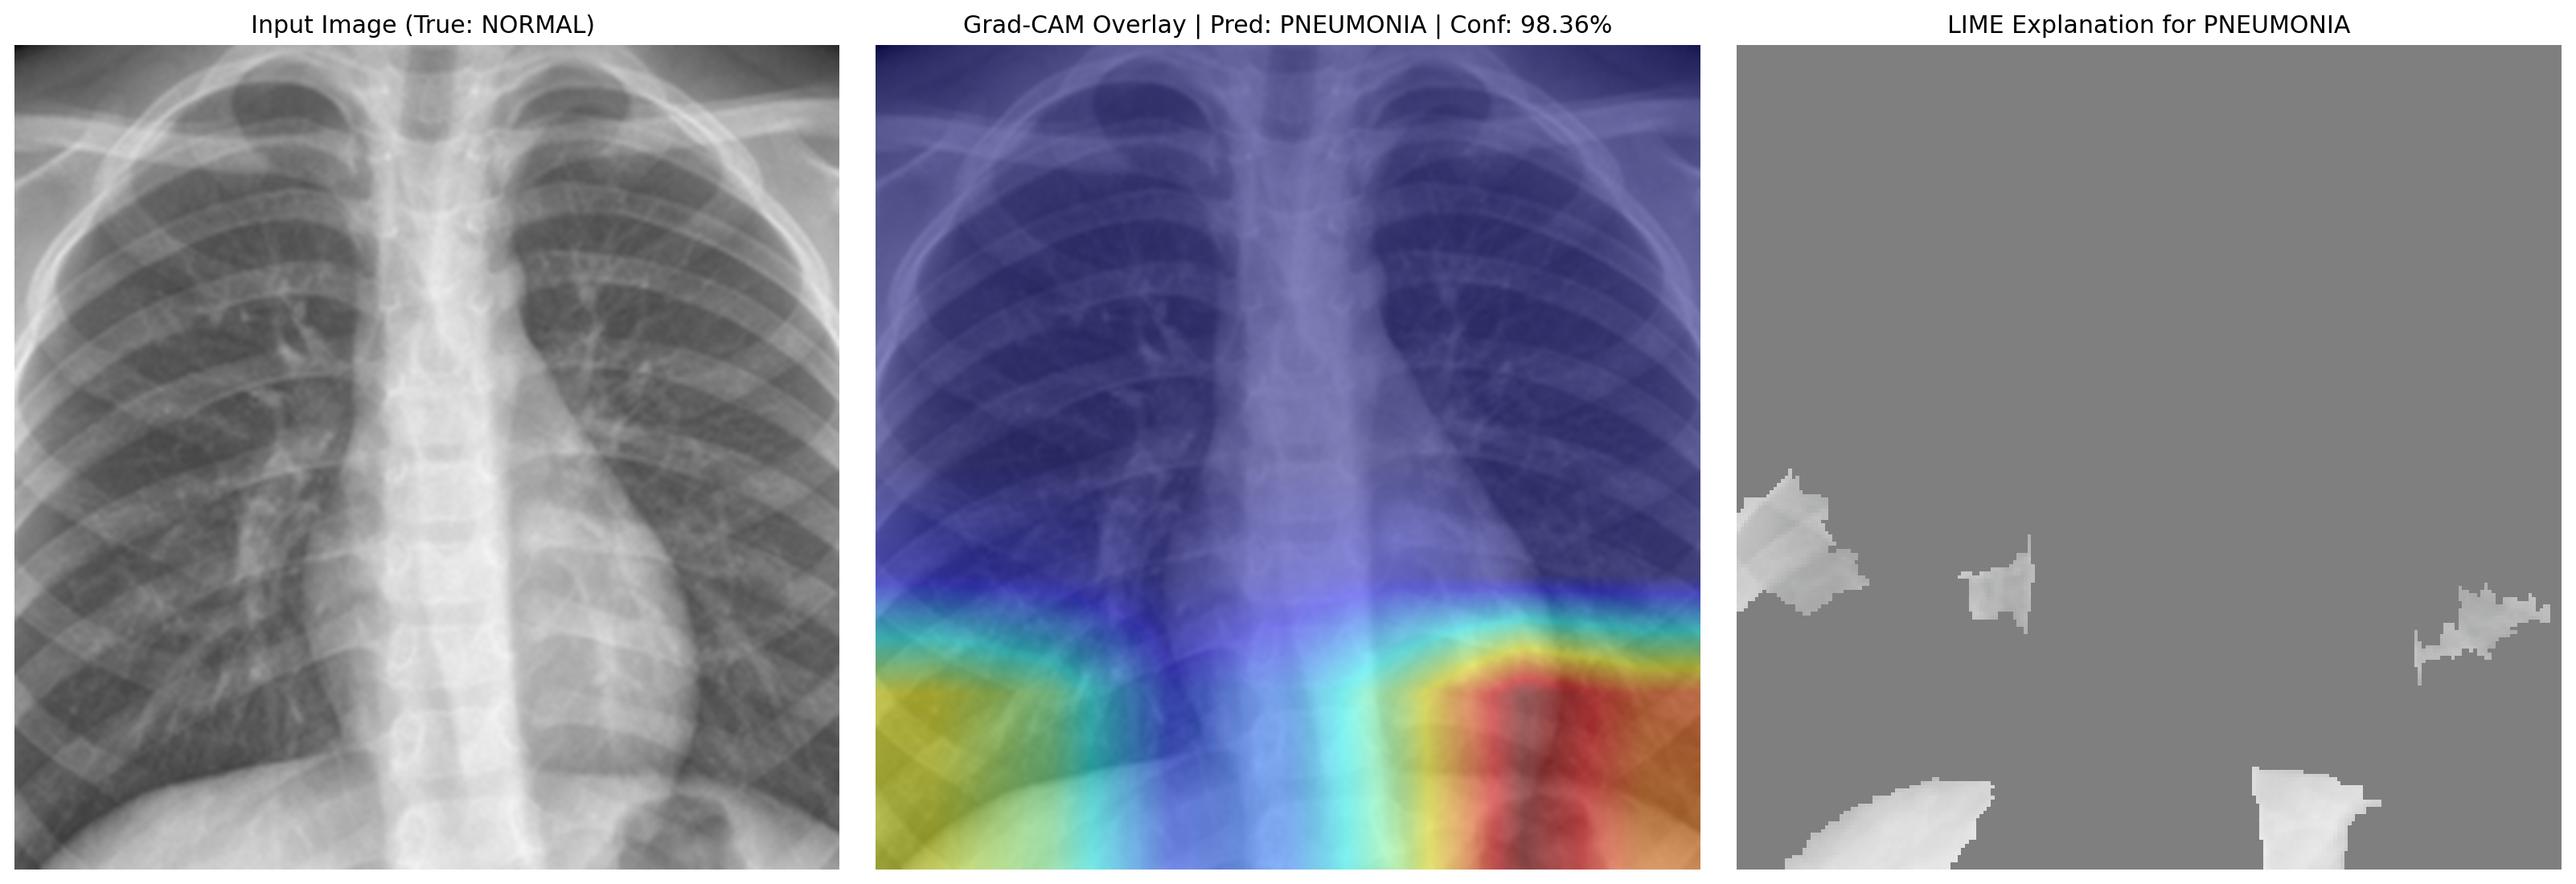

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=CONFIG["display_dpi"])

# Original Image
axes[0].imshow(image_display_pneumonia, interpolation="lanczos")
axes[0].set_title(f"Input Image (True: {class_names[sample_label]}) ")
axes[0].axis("off")

# Grad-CAM Overlay
axes[1].imshow(blended_pneumonia, interpolation="lanczos")
axes[1].set_title(
    f"Grad-CAM Overlay | Pred: {class_names[pred_idx_pneumonia]} | Conf: {confidence_pneumonia:.2%}"
)
axes[1].axis("off")

# LIME Explanation
# LIME's image output is often -1 to 1, scale to 0-1 for display
axes[2].imshow(temp_1 / 2 + 0.5)
axes[2].set_title(f"LIME Explanation for {class_names[class_idx_pneumonia]}")
axes[2].axis('off')

plt.tight_layout()
plt.show()